# MODEL TRAINING


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
import os

train_dir = 'C:/Users/ACER/Desktop/My Code/Micro CNN/crack_detection/train_data'
test_dir = 'C:/Users/ACER/Desktop/My Code/Micro CNN/crack_detection/test_data'

if not os.path.exists(train_dir):
    print("Train directory does not exist.")
else:
    print("Train directory exists.")

if not os.path.exists(test_dir):
    print("Test directory does not exist.")
else:
    print("Test directory exists.")


Train directory exists.
Test directory exists.


In [6]:
img_size = (224, 224)

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator_full = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=32, class_mode='binary', shuffle=True
)


Found 59999 images belonging to 2 classes.


In [7]:
# Limit to 1000 images
x_train, y_train = next(train_generator_full)
for _ in range(31):  # 32 x 32 = 1024 (just over 1000)
    x, y = next(train_generator_full)
    x_train = np.concatenate((x_train, x), axis=0)
    y_train = np.concatenate((y_train, y), axis=0)
x_train = x_train[:1000]
y_train = y_train[:1000]

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=32, class_mode='binary', shuffle=False
)


Found 9997 images belonging to 2 classes.


In [8]:
# === Step 2: Build Model ===
base_model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)


9406464/9406464 [==============================] - 1s 0us/step


In [9]:
# === Step 3: Train Model ===
model.fit(x_train, y_train, epochs=10, validation_data=test_generator, callbacks=[early_stop, checkpoint])


Epoch 1/10
32/32 [==============================] - 149s 5s/step - loss: 0.3638 - accuracy: 0.8630 - val_loss: 0.1205 - val_accuracy: 0.9786
Epoch 2/10


c:\Users\ACER\Desktop\My Code\Micro CNN\model\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


32/32 [==============================] - 136s 4s/step - loss: 0.1140 - accuracy: 0.9740 - val_loss: 0.0754 - val_accuracy: 0.9776
Epoch 3/10
32/32 [==============================] - 127s 4s/step - loss: 0.0731 - accuracy: 0.9790 - val_loss: 0.0701 - val_accuracy: 0.9757
Epoch 4/10
32/32 [==============================] - 123s 4s/step - loss: 0.0561 - accuracy: 0.9850 - val_loss: 0.0655 - val_accuracy: 0.9763
Epoch 5/10
32/32 [==============================] - 133s 4s/step - loss: 0.0474 - accuracy: 0.9890 - val_loss: 0.0593 - val_accuracy: 0.9775
Epoch 6/10
32/32 [==============================] - 128s 4s/step - loss: 0.0426 - accuracy: 0.9890 - val_loss: 0.0590 - val_accuracy: 0.9774
Epoch 7/10
32/32 [==============================] - 127s 4s/step - loss: 0.0341 - accuracy: 0.9910 - val_loss: 0.0601 - val_accuracy: 0.9774
Epoch 8/10
32/32 [==============================] - 128s 4s/step - loss: 0.0336 - accuracy: 0.9890 - val_loss: 0.0630 - val_accuracy: 0.9774
Epoch 9/10
32/32 [======

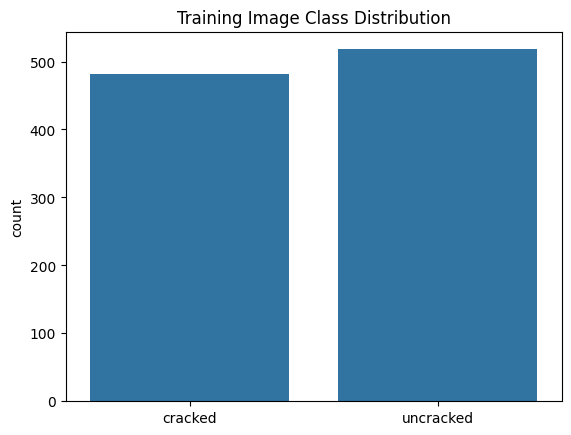

In [11]:
# === Step 4: EDA ===
label_map = train_generator_full.class_indices
labels = ['cracked' if y == 1 else 'uncracked' for y in y_train]
sns.countplot(x=labels)
plt.title("Training Image Class Distribution")
plt.show()


In [14]:
def analyze_crack(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 50, 150)
    
    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if cv2.contourArea(cnt) > 50:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(image, f"Width: {w}px", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
            cv2.putText(image, f"Height: {h}px", (x, y - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Crack Visualization")
    plt.show()

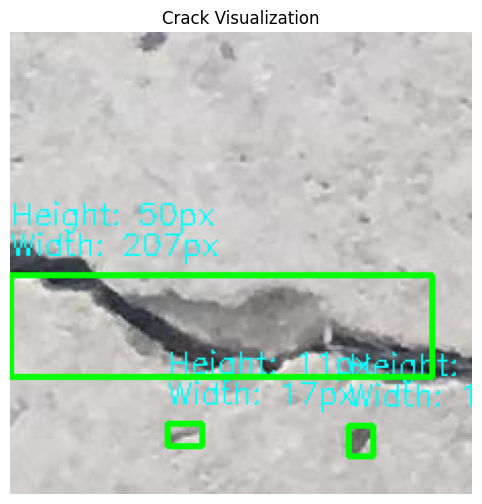

In [21]:
analyze_crack(image_path="C:\\Users\\ACER\\Desktop\\My Code\\Micro CNN\\crack_detection\\test_data\\cracked\\30007.jpg")


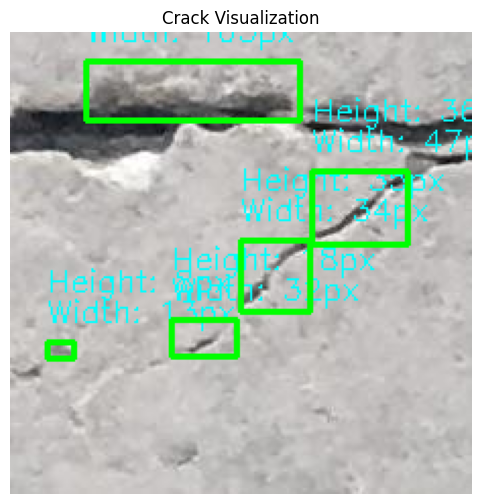

In [23]:
analyze_crack(image_path="C:\\Users\\ACER\\Desktop\\My Code\\Micro CNN\\crack_detection\\test_data\\cracked\\30009.jpg")


313/313 [==============================] - 126s 400ms/step
Classification Report:
               precision    recall  f1-score   support

   Uncracked       0.97      0.99      0.98      4996
     Cracked       0.99      0.96      0.98      5001

    accuracy                           0.98      9997
   macro avg       0.98      0.98      0.98      9997
weighted avg       0.98      0.98      0.98      9997



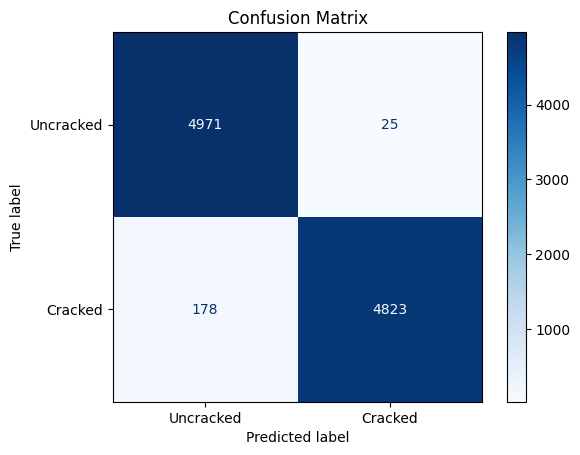

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Step 1: Get predictions
test_generator.reset()
pred_probs = model.predict(test_generator, verbose=1)
preds = (pred_probs > 0.5).astype(int).flatten()

# Step 2: Get true labels
true_labels = test_generator.classes

# Step 3: Confusion matrix and report
cm = confusion_matrix(true_labels, preds)
print("Classification Report:\n", classification_report(true_labels, preds, target_names=['Uncracked', 'Cracked']))

# Step 4: Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Uncracked', 'Cracked'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()